# IMPORTS

In [117]:
import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
from pathlib import Path

# diive 
import importlib.metadata
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")
from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.core.plotting.heatmap_datetime import HeatmapDateTime, HeatmapYearMonth

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)

# Matplotlib defaults
plt.rcParams["figure.autolayout"] = True
plt.rcParams["figure.figsize"] = (10, 4)

diive version: v0.89.0


# LOAD DATA

In [118]:
wd_df = pd.read_csv('../10_METEO/14.1_wind_direction_highres.csv')
wd_df['TIMESTAMP_END'] = pd.to_datetime(wd_df['TIMESTAMP_END'])
wd_df = wd_df.set_index('TIMESTAMP_END')
wd_df['WD_ATMOS'] = wd_df['WD_ATM41_M1_2_1']

wd_df = wd_df['WD_ATMOS']

wd_df

TIMESTAMP_END
2023-11-18 23:04:00    243.8
2023-11-18 23:05:00    226.1
2023-11-18 23:06:00    221.6
2023-11-18 23:07:00    253.0
2023-11-18 23:08:00    215.7
                       ...  
2025-06-04 23:55:00    203.5
2025-06-04 23:56:00    215.8
2025-06-04 23:57:00    206.2
2025-06-04 23:58:00    207.6
2025-06-04 23:59:00    213.5
Name: WD_ATMOS, Length: 767132, dtype: float64

In [119]:
WD_COL = "WD_ATMOS" 

# --- circular helpers ---
def circ_mean_deg(a):
    a = np.deg2rad(np.asarray(a) % 360)
    s, c = np.sin(a).mean(), np.cos(a).mean()
    mu = (np.degrees(np.arctan2(s, c)) + 360) % 360
    return mu

def circ_quantile_band(a, qlow=0.10, qhigh=0.90, ref=None):
    """Return [q_low, q_high] quantiles in degrees, respecting wrap-around, plus span in deg."""
    a = np.asarray(a) % 360
    if a.size == 0:
        return np.nan, np.nan, np.nan
    mu, _ = circ_mean_deg(a) if ref is None else (ref, None)
    shifted = ((a - mu + 180) % 360) - 180  # now linear around 0
    qlo, qhi = np.quantile(shifted, [qlow, qhigh])
    qlo_deg = (qlo + mu + 360) % 360
    qhi_deg = (qhi + mu + 360) % 360
    return qlo_deg, qhi_deg

# --- aggregate per 30-min window ---
def agg_block(series):
    vals = series.dropna().to_numpy() % 360
    if vals.size == 0:
        return pd.Series({"WD_mu": np.nan, "WD_q10": np.nan, "WD_q90": np.nan})
    mu = circ_mean_deg(vals)
    q10, q90 = circ_quantile_band(vals, 0.10, 0.90, ref=mu)
    return pd.Series({"WD_mu": mu, "WD_q10": q10, "WD_q90": q90})

wd_df_agg = (wd_df
             .groupby(pd.Grouper(freq="30min"))
             .apply(agg_block)
             .unstack())

# shift to middle timestamp
wd_df_agg.index = wd_df_agg.index - pd.Timedelta("15min")
wd_df_agg.index.name = "TIMESTAMP_MIDDLE"

wd_df_agg

,WD_mu,WD_q10,WD_q90
TIMESTAMP_MIDDLE,,,
2023-11-18 22:45:00,222.438750,208.30,243.20
2023-11-18 23:15:00,208.016476,194.33,216.73
2023-11-18 23:45:00,199.297945,189.78,209.48
2023-11-19 00:15:00,208.136943,198.59,215.94
2023-11-19 00:45:00,220.659207,205.94,238.19
...,...,...,...
2025-06-04 21:15:00,211.276052,202.92,219.13
2025-06-04 21:45:00,210.469710,203.90,217.20
2025-06-04 22:15:00,205.160150,189.63,221.21


In [120]:
FILEPATH = r"..\\70_USTAR_FILTERING\\72.1_FLUXES_METEO_MGMT_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet"

maindf = load_parquet(filepath=FILEPATH)

maindf

Loaded .parquet file ..\\70_USTAR_FILTERING\\72.1_FLUXES_METEO_MGMT_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet (0.353 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FLAG_L3.3_CUT_50_FN2O_L3.2_QCF0_USTAR_TEST,FN2O_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FN2O_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_16_QCF,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_50_QCF,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_84_QCF,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF_USTAR_TEST,FCH4_L3.3_CUT_16_QCF0,FLAG_L3.3_CUT_16_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_50_QCF0,FLAG_L3.3_CUT_50_FCH4_L3.2_QCF0_USTAR_TEST,FCH4_L3.3_CUT_84_QCF0,FLAG_L3.3_CUT_84_FCH4_L3.2_QCF0_USTAR_TEST
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-31 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2023-11-01 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0,NaN,0.0


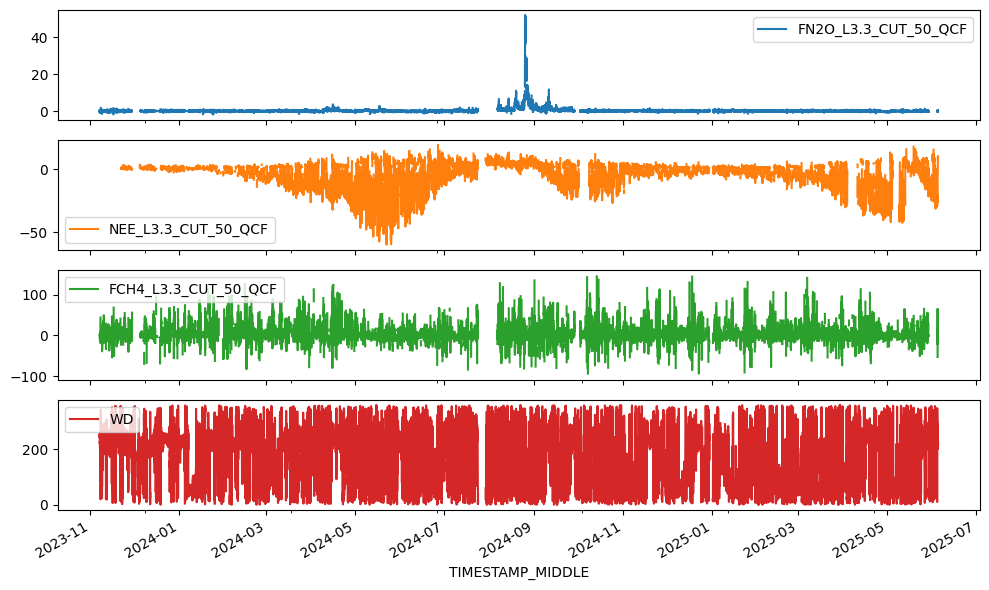

In [121]:
# Select fluxes
FLUXES = ['FN2O_L3.3_CUT_50_QCF', 'NEE_L3.3_CUT_50_QCF', 'FCH4_L3.3_CUT_50_QCF']

# Plot time series 
ax = maindf[FLUXES + ['WD']].plot(subplots=True, figsize=(10, 6), x_compat=True)
plt.show()

# SPLIT INTO PARCELS

We assume the division line lies between 84° and 264°. A symmetric buffer is used to avoid ambiguous assignment.

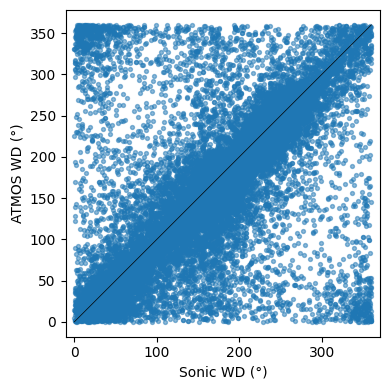

In [122]:
indat = pd.concat([wd_df_agg, maindf['WD']], axis=1)
plt.figure(figsize=(4,4))
plt.scatter(indat['WD'] % 360, indat['WD_mu'] % 360, s=8, alpha=0.5)
plt.xlabel('Sonic WD (°)'); plt.ylabel('ATMOS WD (°)')
plt.axis('equal'); plt.tight_layout()
plt.plot([0, 360], [0, 360], 'k-', lw=0.5)  # Add 1:1 line

In [123]:
q10 = wd_df_agg["WD_q10"]
q90 = wd_df_agg["WD_q90"]

# band wraps across 0° if q10 > q90
wrap = (q10 > q90)

# B sector: entire band within 84–264 (cannot be wrap-around)
mask_B = (~wrap) & (q10 >= 84) & (q90 <= 264)

# A sector: entire band below 84 OR entirely above 264 OR wrap-around (near 0°)
mask_A = ((q10 < 84) & (q90 < 84)) | ((q10 > 264) & (q90 > 264)) | wrap

wd_df_agg['parcel_pred'] = np.nan
wd_df_agg.loc[mask_A, 'parcel_pred'] = 'A'
wd_df_agg.loc[mask_B, 'parcel_pred'] = 'B'

wd_df_agg

,WD_mu,WD_q10,WD_q90,parcel_pred
TIMESTAMP_MIDDLE,,,,
2023-11-18 22:45:00,222.438750,208.30,243.20,B
2023-11-18 23:15:00,208.016476,194.33,216.73,B
2023-11-18 23:45:00,199.297945,189.78,209.48,B
2023-11-19 00:15:00,208.136943,198.59,215.94,B
2023-11-19 00:45:00,220.659207,205.94,238.19,B
...,...,...,...,...
2025-06-04 21:15:00,211.276052,202.92,219.13,B
2025-06-04 21:45:00,210.469710,203.90,217.20,B
2025-06-04 22:15:00,205.160150,189.63,221.21,B


In [124]:
# Splitting by wind direction
buffer = 10  # degrees
mask_A = (maindf['WD'] < (84 - buffer)) | (maindf['WD'] > (264 + buffer))
mask_B = (maindf['WD'] > (84 + buffer)) & (maindf['WD'] < (264 - buffer))

maindf.loc[maindf['WD'].notna(), 'parcel'] = 'buffer'
maindf.loc[mask_A, 'parcel'] = 'A'
maindf.loc[mask_B, 'parcel'] = 'B'

# Data loss to buffer
for flux in FLUXES:
    total_count = maindf[flux].notna().sum()
    buffer_count = maindf.loc[maindf['parcel']=='buffer', flux].notna().sum()
    perc_loss = buffer_count / total_count * 100 if total_count else np.nan
    print(f"{flux}: {perc_loss:.2f}% lost to buffer ({buffer}°)")

FN2O_L3.3_CUT_50_QCF: 9.09% lost to buffer (10°)
NEE_L3.3_CUT_50_QCF: 10.02% lost to buffer (10°)
FCH4_L3.3_CUT_50_QCF: 8.86% lost to buffer (10°)


In [125]:
maindf = pd.concat([maindf, wd_df_agg[['parcel_pred', 'WD_mu']]], axis=1)  # Add predicted parcel based on ATMOS WD  

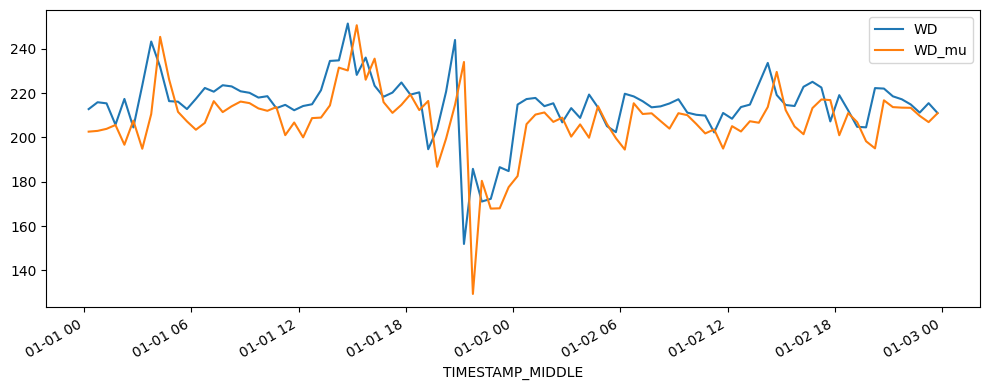

In [134]:
indat = maindf[['WD', 'WD_mu']]['2024-01-01':'2024-01-02'].copy()
indat.plot(x_compat=True);

# PLOTS

based on sonic mean wind direction

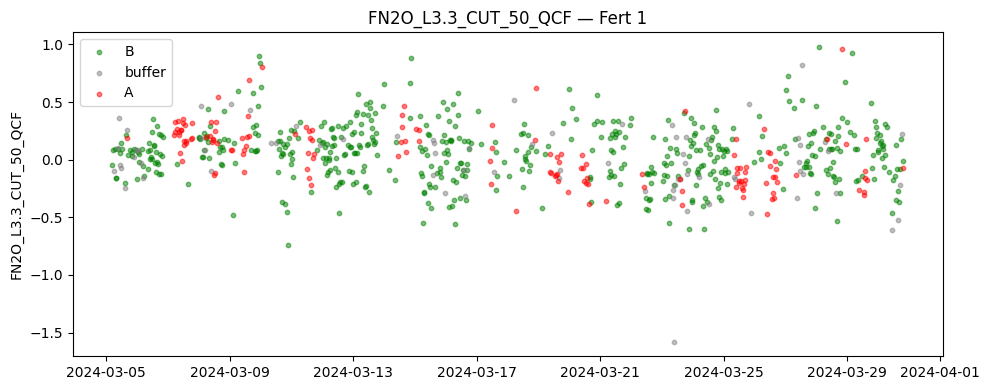

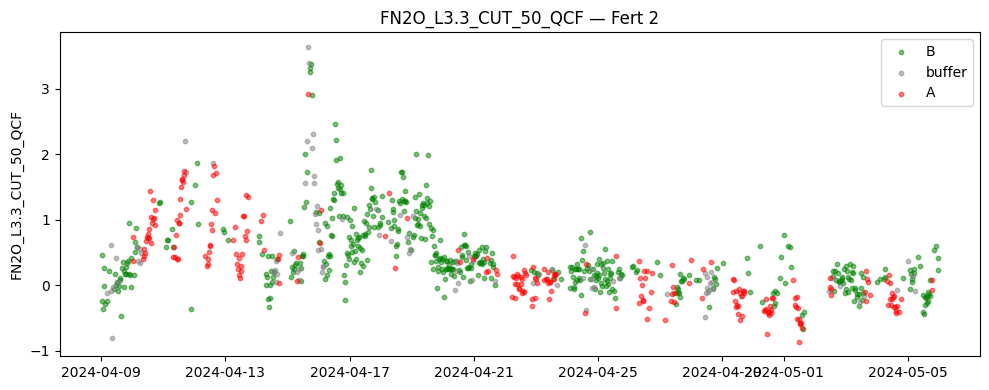

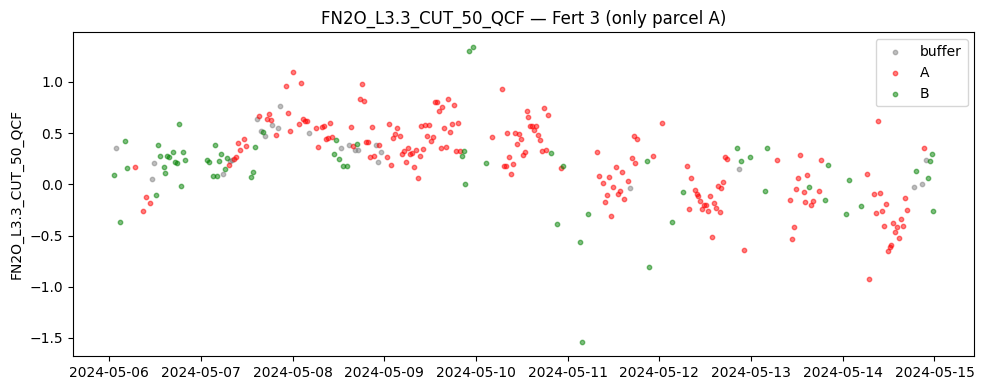

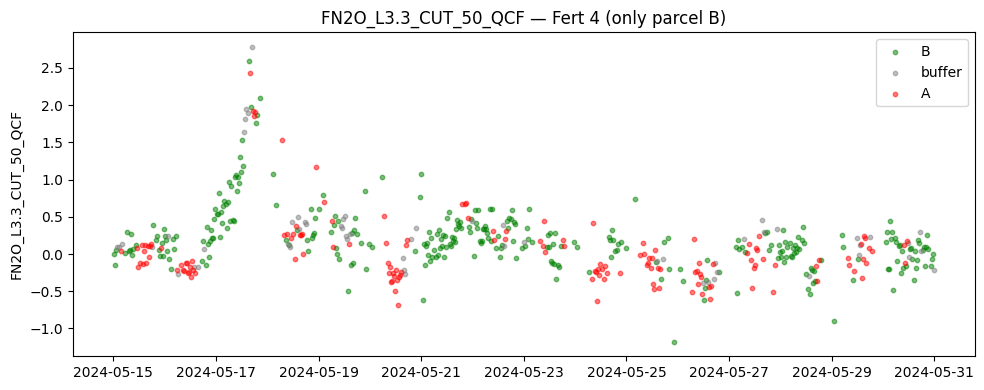

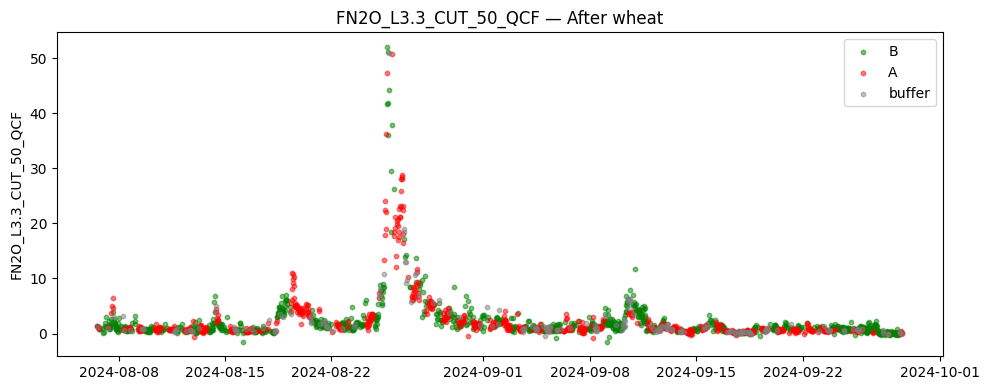

In [53]:
# --- Period definitions ---
periods = [
    ("Fert 1",  "2024-03-05", "2024-03-30"),
    ("Fert 2",  "2024-04-09", "2024-05-05"),
    ("Fert 3 (only parcel A)", "2024-05-06", "2024-05-14"),
    ("Fert 4 (only parcel B)", "2024-05-15", "2024-05-30"),
    ("After wheat", "2024-08-01", "2024-10-01"),
]

flux = FLUXES[0]  # pick which flux to show in period scatter plots
fixed_colors = {'A': 'red', 'B': 'green', 'buffer': 'gray'}

for label, start, end in periods:
    indat = maindf.loc[start:end].copy()
    if indat.empty:
        print(f"No data for period: {label} ({start} to {end})")
        continue

    parcels = indat['parcel'].dropna().unique()

    plt.figure(figsize=(10, 4))
    for parcel in parcels:
        sub = indat[indat['parcel'] == parcel]
        if sub.empty or (flux not in sub.columns):
            continue
        plt.scatter(sub.index, sub[flux], label=str(parcel), s=10, alpha=0.5,
                    color=fixed_colors.get(parcel))

    plt.title(f"{flux} — {label}")
    plt.xlabel('')
    plt.ylabel(flux)
    plt.legend()
    plt.tight_layout()
    plt.show()

based on ATMOS WD range

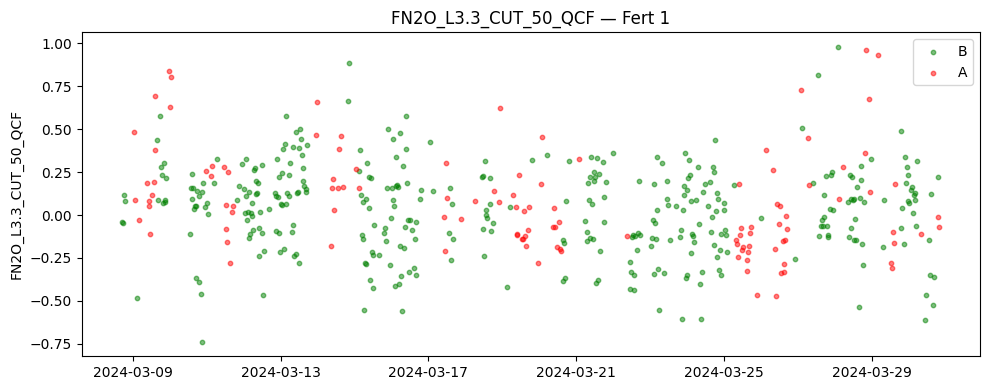

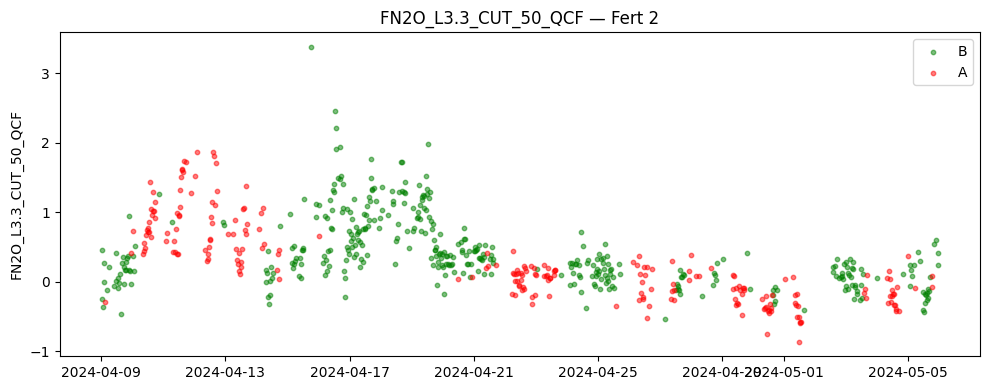

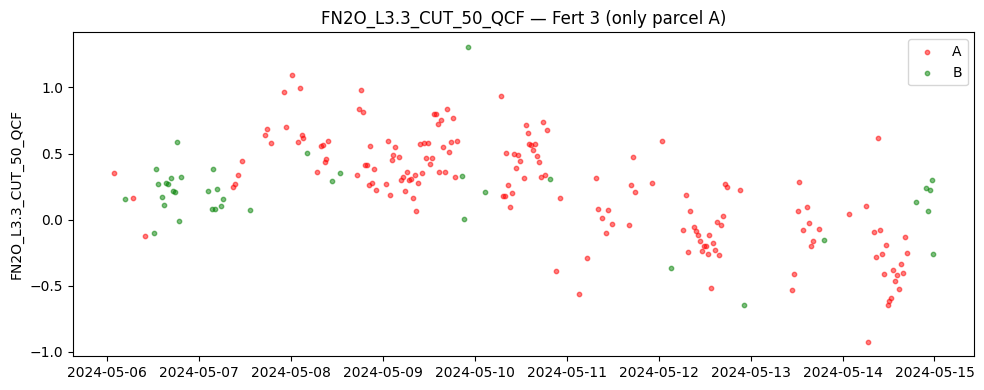

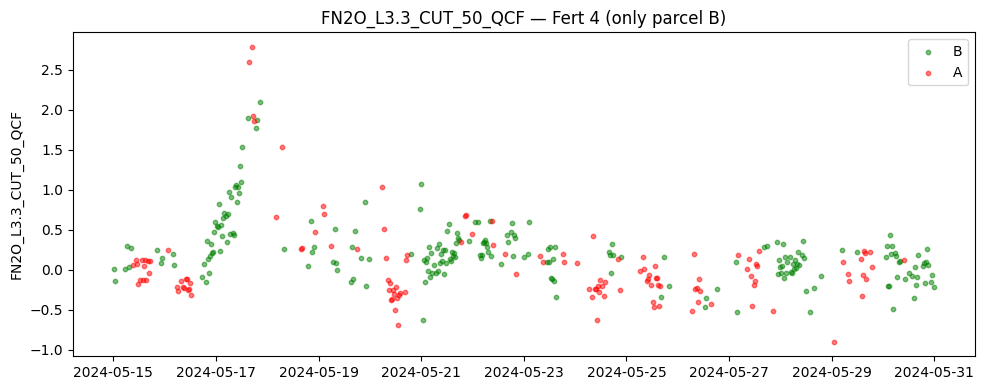

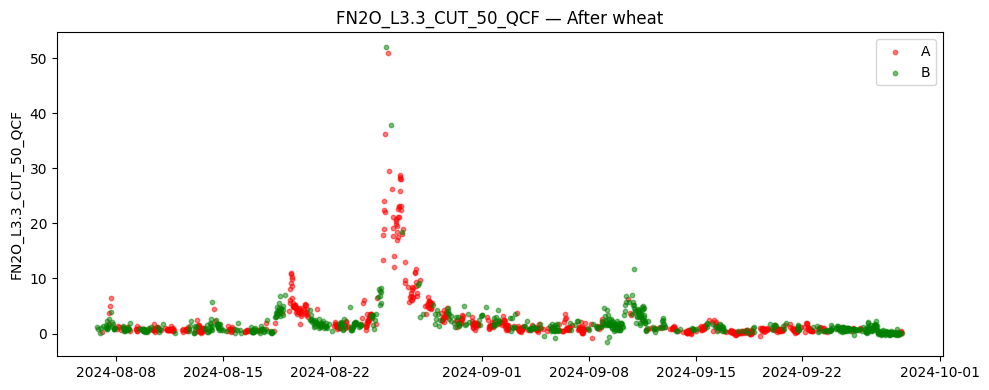

In [113]:
# --- Period definitions ---
periods = [
    ("Fert 1",  "2024-03-05", "2024-03-30"),
    ("Fert 2",  "2024-04-09", "2024-05-05"),
    ("Fert 3 (only parcel A)", "2024-05-06", "2024-05-14"),
    ("Fert 4 (only parcel B)", "2024-05-15", "2024-05-30"),
    ("After wheat", "2024-08-01", "2024-10-01"),
]

flux = FLUXES[0]  # pick which flux to show in period scatter plots
fixed_colors = {'A': 'red', 'B': 'green'}
for label, start, end in periods:
    indat = maindf.loc[start:end].copy()
    if indat.empty:
        print(f"No data for period: {label} ({start} to {end})")
        continue

    parcels = indat['parcel_pred'].dropna().unique()

    plt.figure(figsize=(10, 4))
    for parcel in parcels:
        sub = indat[indat['parcel_pred'] == parcel]
        if sub.empty or (flux not in sub.columns):
            continue
        plt.scatter(sub.index, sub[flux], label=str(parcel), s=10, alpha=0.5,
                    color=fixed_colors.get(parcel))

    plt.title(f"{flux} — {label}")
    plt.xlabel('')
    plt.ylabel(flux)
    plt.legend()
    plt.tight_layout()
    plt.show()

# COMPARE TRT

based on sonic

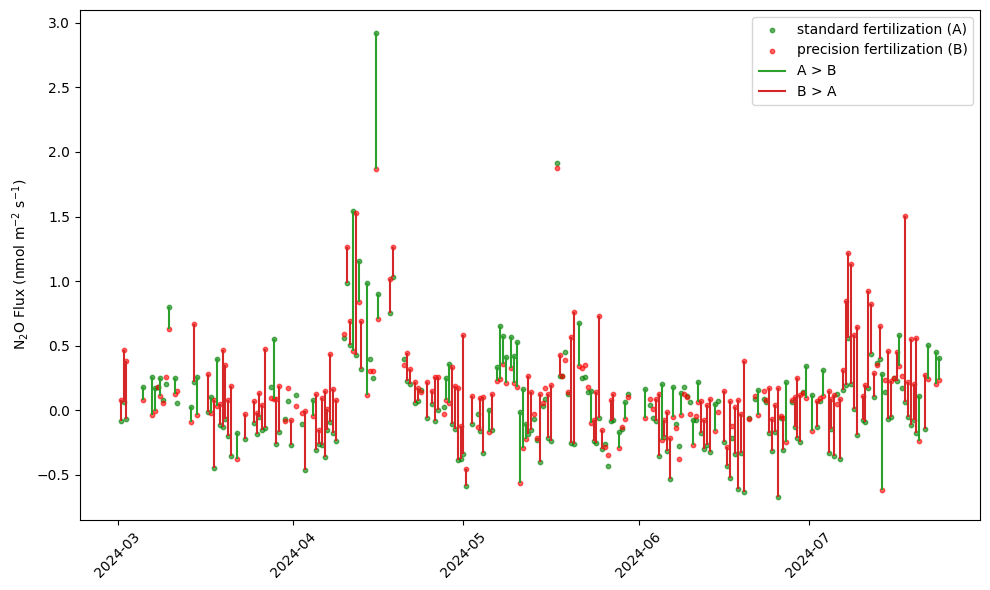

In [54]:
# Define period of interest
df_n2o = maindf['2024-03-01':'2024-07-30'].copy()

# Build parcel-specific series for FN2O flux ---
df_n2o = df_n2o[['FN2O_L3.3_CUT_50_QCF', 'parcel']].copy()
df_n2o['n2o_flux_A'] = np.nan
df_n2o['n2o_flux_B'] = np.nan
mask_A = df_n2o['parcel'] == 'A'
mask_B = df_n2o['parcel'] == 'B'
df_n2o.loc[mask_A, 'n2o_flux_A'] = df_n2o.loc[mask_A, 'FN2O_L3.3_CUT_50_QCF']
df_n2o.loc[mask_B, 'n2o_flux_B'] = df_n2o.loc[mask_B, 'FN2O_L3.3_CUT_50_QCF']

df_n2o = df_n2o.drop(columns=['parcel', 'FN2O_L3.3_CUT_50_QCF'])

# Resample (specify the period and the aggregation method)
resampled_df = df_n2o.resample('12h').median()

# Difference (A - B)
resampled_df['flux_difference_A-B'] = resampled_df['n2o_flux_A'] - resampled_df['n2o_flux_B']

# Detection limit filter (|Δ| > 0.1 nmol m^-2 s^-1)
#resampled_df = resampled_df[resampled_df['flux_difference_A-B'].abs() > 0.1]

# Ensure pairs: drop rows where either A or B is NaN
resampled_df = resampled_df.dropna(how='any')

# Paired scatter with connecting lines
a = resampled_df['n2o_flux_A']
b = resampled_df['n2o_flux_B']
x = resampled_df.index

eps = 0.1  # set to 0.1 if you want your detection limit
pos = a > b + eps   # A > B
neg = b > a + eps   # B > A

plt.figure(figsize=(10, 6))
plt.scatter(x, a, label='standard fertilization (A)', c='green', s=10, alpha=0.6)
plt.scatter(x, b, label='precision fertilization (B)', c='red', s=10, alpha=0.6)

# vertical connectors
plt.vlines(x[pos], ymin=b[pos], ymax=a[pos], colors='tab:green', alpha=1, linewidth=1.5, label='A > B')
plt.vlines(x[neg], ymin=a[neg], ymax=b[neg], colors='tab:red',   alpha=1, linewidth=1.5, label='B > A')

plt.ylabel('N$_{2}$O Flux (nmol m$^{-2}$ s$^{-1}$)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

based on atmos

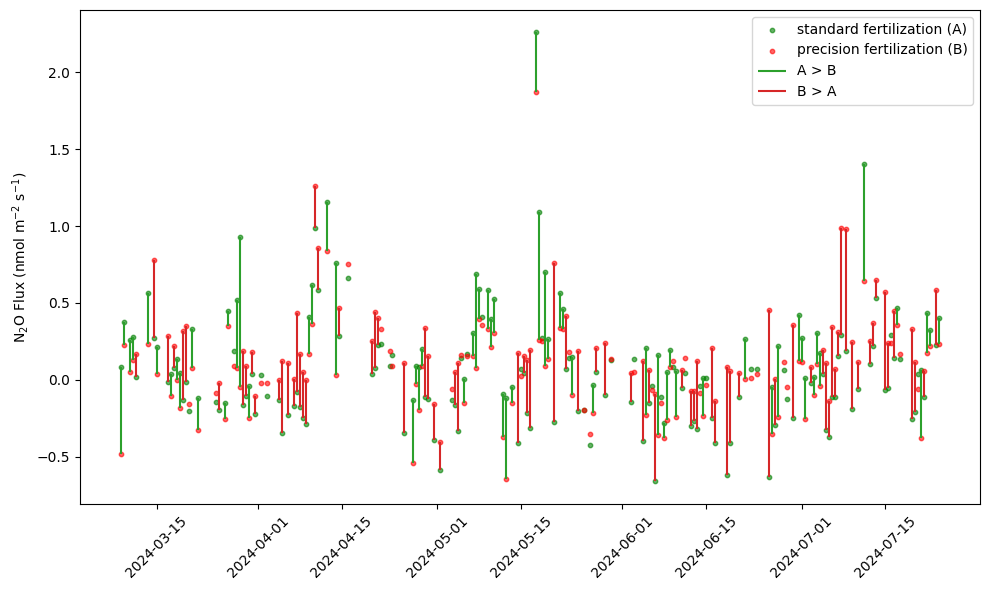

In [116]:
# Define period of interest
df_n2o = maindf['2024-03-01':'2024-07-30'].copy()

# Build parcel-specific series for FN2O flux ---
df_n2o = df_n2o[['FN2O_L3.3_CUT_50_QCF', 'parcel_pred']].copy()
df_n2o['n2o_flux_A'] = np.nan
df_n2o['n2o_flux_B'] = np.nan
mask_A = df_n2o['parcel_pred'] == 'A'
mask_B = df_n2o['parcel_pred'] == 'B'
df_n2o.loc[mask_A, 'n2o_flux_A'] = df_n2o.loc[mask_A, 'FN2O_L3.3_CUT_50_QCF']
df_n2o.loc[mask_B, 'n2o_flux_B'] = df_n2o.loc[mask_B, 'FN2O_L3.3_CUT_50_QCF']

df_n2o = df_n2o.drop(columns=['parcel_pred', 'FN2O_L3.3_CUT_50_QCF'])

# Resample (specify the period and the aggregation method)
resampled_df = df_n2o.resample('12h').median()

# Difference (A - B)
resampled_df['flux_difference_A-B'] = resampled_df['n2o_flux_A'] - resampled_df['n2o_flux_B']

# Detection limit filter (|Δ| > 0.1 nmol m^-2 s^-1)
#resampled_df = resampled_df[resampled_df['flux_difference_A-B'].abs() > 0.1]

# Ensure pairs: drop rows where either A or B is NaN
resampled_df = resampled_df.dropna(how='any')

# Paired scatter with connecting lines
a = resampled_df['n2o_flux_A']
b = resampled_df['n2o_flux_B']
x = resampled_df.index

eps = 0.1  # set to 0.1 if you want your detection limit
pos = a > b + eps   # A > B
neg = b > a + eps   # B > A

plt.figure(figsize=(10, 6))
plt.scatter(x, a, label='standard fertilization (A)', c='green', s=10, alpha=0.6)
plt.scatter(x, b, label='precision fertilization (B)', c='red', s=10, alpha=0.6)

# vertical connectors
plt.vlines(x[pos], ymin=b[pos], ymax=a[pos], colors='tab:green', alpha=1, linewidth=1.5, label='A > B')
plt.vlines(x[neg], ymin=a[neg], ymax=b[neg], colors='tab:red',   alpha=1, linewidth=1.5, label='B > A')

plt.ylabel('N$_{2}$O Flux (nmol m$^{-2}$ s$^{-1}$)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cumulative sums (A vs B)

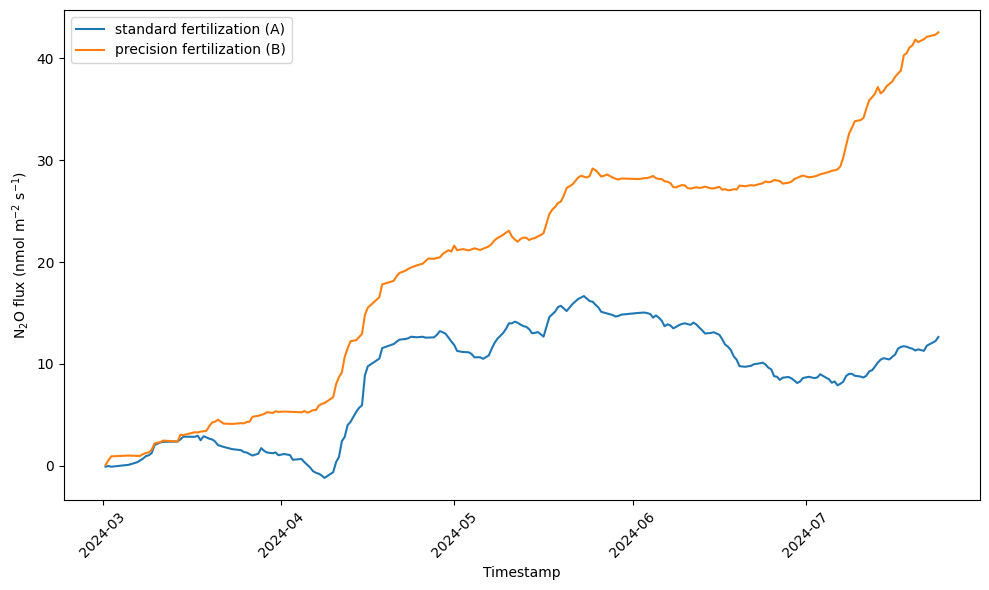

In [55]:
# Cumulative sums
cum_df = pd.DataFrame(index=resampled_df.index)
cum_df['n2o_flux_A'] = resampled_df['n2o_flux_A'].cumsum()
cum_df['n2o_flux_B'] = resampled_df['n2o_flux_B'].cumsum()

# Plot cumulative sums
plt.figure(figsize=(10, 6))
plt.plot(cum_df.index, cum_df['n2o_flux_A'], label='standard fertilization (A)')
plt.plot(cum_df.index, cum_df['n2o_flux_B'], label='precision fertilization (B)')
plt.xlabel('Timestamp')
plt.ylabel('N$_{2}$O flux (nmol m$^{-2}$ s$^{-1}$)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Difference series and statistics

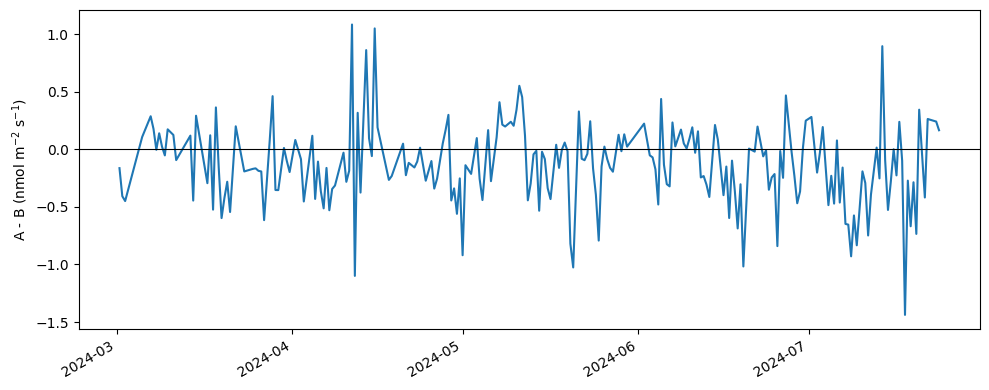

Average difference (A - B): -0.133 nmol m^-2 s^-1
T-statistic: -5.676, p-value: 4.26e-08


In [56]:
# Difference time series
ax = resampled_df['flux_difference_A-B'].plot(kind='line', figsize=(10, 4), x_compat=True)
ax.axhline(0, color='black', linewidth=0.8)  # Add zero line
ax.set_ylabel('A - B (nmol m$^{-2}$ s$^{-1}$)')
ax.set_xlabel('')
plt.show()

# Average difference
avg_diff = resampled_df['flux_difference_A-B'].mean()
print(f"Average difference (A - B): {avg_diff:.3f} nmol m^-2 s^-1")

# Paired t-test
t_stat, p_value = stats.ttest_rel(resampled_df['n2o_flux_A'], resampled_df['n2o_flux_B'])
print(f"T-statistic: {t_stat:.3f}, p-value: {p_value:.3g}")